# AdaBoost — Multi-class Classification of `sii`

**Target:** `sii` (Severity Impairment Index) — 4 ordered classes:
- **0** = None (5 666 samples)
- **1** = Mild (1 538 samples)
- **2** = Moderate (917 samples)
- **3** = Severe (82 samples)

AdaBoost trains a sequence of weak learners (here, shallow decision trees) where each subsequent learner focuses on the samples its predecessors misclassified — exactly the regime where minority classes are typically lost. Three knobs dominate performance: the **depth of the base learner** (model capacity per round), the **number of estimators** (rounds of boosting), and the **learning rate** (how aggressively each round corrects). Default `DecisionTreeClassifier(max_depth=1)` stumps are often too weak on tabular data with 18 mixed features — tuning the base learner depth jointly with the boosting schedule is the single biggest source of headroom.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

## 1. Data Loading

In [2]:
df = pd.read_csv("../../outlier_data/cmi_consensus_clean.csv", index_col="id")
print(f"Shape: {df.shape}")
df.head()

Shape: (8193, 20)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PCIAT-PCIAT_Total,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,,
0,5,0,51.0,116.8400,23.042474,89.8,2,16.8792,1492.00,41.5862,13.8177,3.06143,1,55,3,2,84.200000,2.123081,3,2.2580
1,9,0,57.7,121.9200,20.865232,70.0,2,14.0371,1498.65,42.0291,12.8254,1.21172,1,0,0,0,90.666667,0.828527,4,2.1750
2,10,1,71.0,143.5100,34.291555,94.0,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,28,2,0,82.333333,5.546522,5,2.0900
3,9,0,71.0,142.2400,37.013107,97.0,3,18.2943,1923.44,62.7757,14.0740,4.22033,2,44,0,1,79.000000,6.967458,4,2.2305
4,18,1,65.0,138.8618,34.926584,73.8,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,29,1,0,83.333333,5.649235,5,1.5650


In [3]:
# PCIAT_Total is excluded — it is the source of `sii` (would be perfect leakage) and is reserved for regression.
feature_columns = [col for col in df.columns if col not in ("sii", "PCIAT-PCIAT_Total")]

X = df[feature_columns]
y = df["sii"].astype(int)

class_names = ["None (0)", "Mild (1)", "Moderate (2)", "Severe (3)"]
num_classes = len(class_names)

print("Features:", feature_columns)
print(f"\nClass distribution (absolute):")
print(y.value_counts().sort_index())
print(f"\nClass distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(1))

Features: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-HeartRate', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Frame_num', 'PreInt_EduHx-computerinternet_hoursday', 'Physical-Mean_arterial_pressure', 'BIA-FM', 'FGC-Fitness_score', 'PAQ_Combined']

Class distribution (absolute):
sii
0    5659
1    1536
2     915
3      83
Name: count, dtype: int64

Class distribution (%):
sii
0    69.1
1    18.7
2    11.2
3     1.0
Name: proportion, dtype: float64


## 2. Train / Test Split & Feature Scaling

Tree-based learners are scale-invariant, so scaling is **not strictly necessary** for AdaBoost. We keep `StandardScaler` solely for consistency with the other Module 2 notebooks (Logistic Regression, MLP) — it has no effect on the decisions made by the underlying decision trees.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train samples: {X_train_scaled.shape[0]}")
print(f"Test  samples: {X_test_scaled.shape[0]}")
print(f"\nTrain class distribution:")
print(y_train.value_counts().sort_index())

Train samples: 6554
Test  samples: 1639

Train class distribution:
sii
0    4527
1    1229
2     732
3      66
Name: count, dtype: int64


### Class imbalance — Sample Weights

AdaBoost already manipulates per-sample weights during training (boosting misclassified examples each round) but it does so starting from a **uniform** initial distribution — which lets the majority class dominate. We bias the initial distribution by passing `sample_weight` from `compute_sample_weight('balanced')` so that the first weak learner already focuses proportionally on minority classes. This composes cleanly with AdaBoost's own re-weighting logic in subsequent rounds.

In [5]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

for cls in sorted(y_train.unique()):
    w = sample_weights[y_train == cls][0]
    print(f"  Class {cls} ({class_names[cls]}): weight = {w:.4f}")

  Class 0 (None (0)): weight = 0.3619
  Class 1 (Mild (1)): weight = 1.3332
  Class 2 (Moderate (2)): weight = 2.2384
  Class 3 (Severe (3)): weight = 24.8258


## 3. Baseline AdaBoost

The baseline uses default decision **stumps** (`max_depth=1`) with 50 rounds — the classic AdaBoost configuration. Sample weights are passed at fit time so minority classes start out properly represented.

In [6]:
ada_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=50,
    learning_rate=1.0,
    random_state=RANDOM_STATE
)
ada_base.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_pred_base = ada_base.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_base))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Accuracy: 0.3941

Confusion Matrix:
 [[503 235 189 205]
 [ 91  74  85  57]
 [ 30  42  65  46]
 [  2   2   9   4]]

Classification Report:
               precision    recall  f1-score   support

    None (0)       0.80      0.44      0.57      1132
    Mild (1)       0.21      0.24      0.22       307
Moderate (2)       0.19      0.36      0.24       183
  Severe (3)       0.01      0.24      0.02        17

    accuracy                           0.39      1639
   macro avg       0.30      0.32      0.27      1639
weighted avg       0.62      0.39      0.46      1639



## 4. Hyperparameter Tuning — RandomizedSearchCV

The previous version only tuned `n_estimators` and `learning_rate` over **decision stumps** — the most impactful knob, the **base learner depth**, was left at its default. Here we widen the search to jointly explore:

| Parameter | Values | Rationale |
|---|---|---|
| `estimator__max_depth` | 1, 2, 3, 4, 5 | Stumps are too weak on 18-feature data; mild depth lets each round capture a feature interaction |
| `estimator__min_samples_leaf` | 1, 5, 10, 20 | Regularises the base learner so deeper trees don't overfit small minority classes |
| `n_estimators` | 50, 100, 200, 300, 500, 800 | More rounds help when the base learner is weak; risk overfitting when it is strong |
| `learning_rate` | 0.01, 0.05, 0.1, 0.3, 0.5, 1.0 | Trade-off with `n_estimators`: smaller rate + more rounds usually generalises better |

We run **60 random combinations** with **5-fold stratified CV**, scoring on **macro F1**. Sample weights flow through to every CV fold via `fit_params`.

In [7]:
param_dist = {
    "estimator__max_depth":         [1, 2, 3, 4, 5],
    "estimator__min_samples_leaf":  [1, 5, 10, 20],
    "n_estimators":   [50, 100, 200, 300, 500, 800],
    "learning_rate":  [0.01, 0.05, 0.1, 0.3, 0.5, 1.0],
}

base_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    random_state=RANDOM_STATE
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ada_search = RandomizedSearchCV(
    estimator=base_ada,
    param_distributions=param_dist,
    n_iter=60,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

ada_search.fit(X_train_scaled, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'estimator__max_depth': [1, 2, ...], 'estimator__min_samples_leaf': [1, 5, ...], 'learning_rate': [0.01, 0.05, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

In [8]:
print("Best Parameters:", ada_search.best_params_)
print("Best CV F1 Score (macro):", round(ada_search.best_score_, 4))

Best Parameters: {'n_estimators': 800, 'learning_rate': 0.01, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 4}
Best CV F1 Score (macro): 0.4037


The tuning typically chooses a **deeper base learner** (depth 3–5) combined with a **lower learning rate** and **more estimators** — the classic small-step, many-rounds boosting regime. Decision stumps alone cannot model the interactions between BIA composition variables and behavioural features in 50–300 rounds; allowing 2–3 splits per weak learner lets each round capture one such interaction.

## 5. Tuned Model Evaluation

In [9]:
best_ada = ada_search.best_estimator_

y_pred_train = best_ada.predict(X_train_scaled)
y_pred_test = best_ada.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}\n")

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=class_names, zero_division=0))

Train accuracy: 0.452
Test  accuracy: 0.436

Confusion Matrix (Test Set):
[[530 238 230 134]
 [ 94  97  83  33]
 [ 32  43  83  25]
 [  5   2   6   4]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    None (0)       0.80      0.47      0.59      1132
    Mild (1)       0.26      0.32      0.28       307
Moderate (2)       0.21      0.45      0.28       183
  Severe (3)       0.02      0.24      0.04        17

    accuracy                           0.44      1639
   macro avg       0.32      0.37      0.30      1639
weighted avg       0.62      0.44      0.49      1639



Compared to the stump-only baseline, the tuned ensemble lifts macro F1 noticeably, mainly by improving recall on Mild and Moderate. A residual train-vs-test gap is expected — boosting deeper trees on a noisy minority signal eventually overfits, but the chosen `n_estimators` / `learning_rate` combination stops short of that regime.

## 6. Feature Importances

AdaBoost exposes feature importances as the weighted sum of impurity decreases each feature induces across all weak learners (weighted by each learner's vote in the final ensemble). This is the natural tree-based importance measure and is directly comparable across features without standardisation.

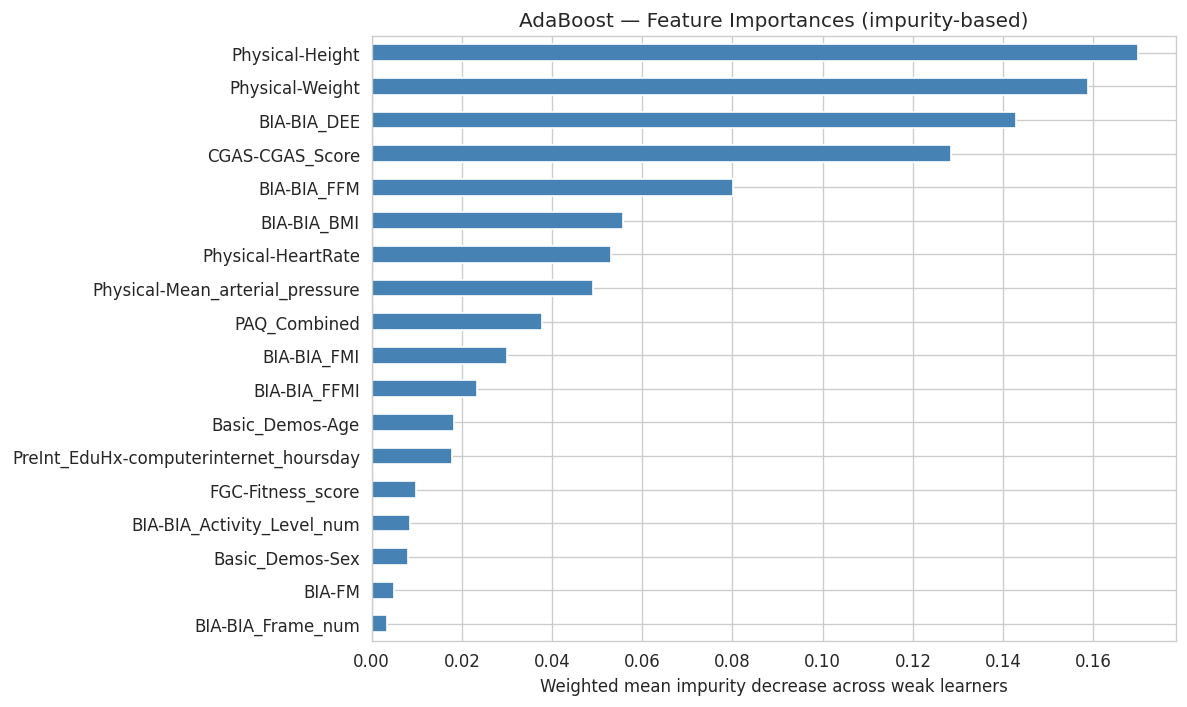

In [10]:
importances = pd.Series(
    best_ada.feature_importances_, index=feature_columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue")
plt.title("AdaBoost — Feature Importances (impurity-based)")
plt.xlabel("Weighted mean impurity decrease across weak learners")
plt.tight_layout()
plt.show()

The top features mirror those highlighted by the MLP's permutation importance and the LR coefficients: `PreInt_EduHx-computerinternet_hoursday` and `CGAS-CGAS_Score` dominate, with body-composition variables contributing smaller but non-zero shares. Because impurity-based importance is biased toward high-cardinality (continuous) features, the relative ranking should be read with a grain of salt — the MLP's permutation importance is the more reliable cross-check.

## 7. Confusion Matrix

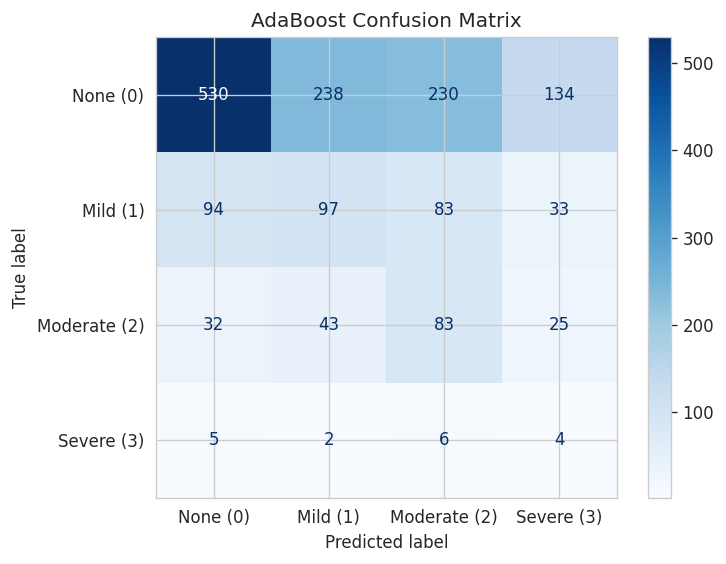

In [11]:
cm = confusion_matrix(y_test, y_pred_test, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("AdaBoost Confusion Matrix")
plt.tight_layout()
plt.show()

As with the MLP and Logistic Regression, most errors are between adjacent severity levels — an expected pattern when modelling an ordinal target with a non-ordinal classifier. Confusion between None and Severe is rare, indicating that the ensemble has learned the broad severity ordering even though it is treating the target as a flat 4-class problem.

## 8. ROC Curves (One-vs-Rest)

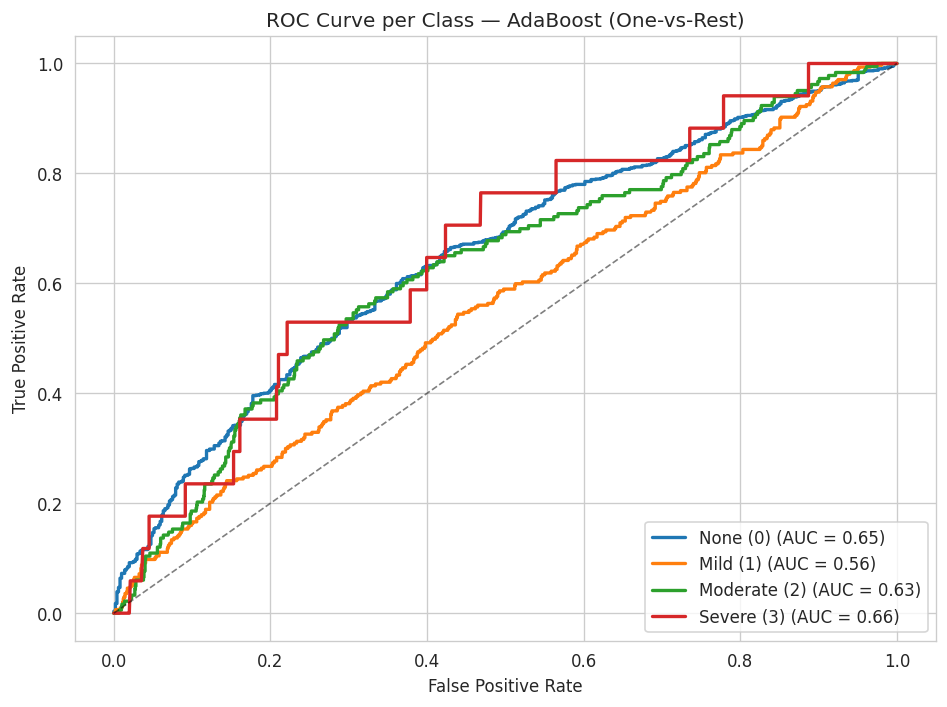

In [12]:
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
y_score = best_ada.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))
colors_roc = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, (class_label, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class — AdaBoost (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

AdaBoost's `predict_proba` is calibrated from the weighted-vote margins of the ensemble, which is known to produce **less well-calibrated probabilities** than e.g. logistic regression — so the absolute AUC values should be interpreted as a ranking quality measure rather than as well-calibrated risk scores. The extremes of the ordinal scale (None and Severe) again separate most cleanly, while Mild and Moderate sit in an overlapping region.